In [11]:
%load_ext autoreload
%autoreload 2

import numpy as np
import tqdm, utils, theory, pickle, cluster_utils, data, torch, sgd_utils
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cpu')
ON_CLUSTER, data_path, output_home_path = cluster_utils.initialize()
parser = cluster_utils.Args()
parser.add('P', 1000, help='size of training set per task')
parser.add('P_test', 500, help='size of test set per task')
parser.add('N', 2000, help='hidden layer width')
parser.add('n_tasks', 2, help='number of tasks in the sequence')
parser.add('eta', 0.01, help='learning rate')
parser.add('T', 0.0, help='temperature')
parser.add('sigma', 0.2, help='weight variance')
parser.add('depth', 3, help='num of hidden layers. setting depth=0 would use the input kernel')
parser.add('seed', 0, help='random seed')
parser.add('l2', 0.0, help='l2 regularizer')
parser.add('dataset', 'mnist', help='dataset to use: mnist/cifar')
parser.add('permutation', 1.0, help='whether or not to permute the dataset')
parser.add('n_epochs', 1, help='number of times to go through the sequence of tasks')
parser.add('n_steps', 5000, help='number of SGD steps')
args = parser.parse_args()

args.P = np.min([args.P, int(50000 / args.n_tasks)])
args.P_test = np.min([args.P, int(10000 / args.n_tasks)])

run_name = f'{args.BATCH_NAME}_{args.TRIAL_IND}'

logger = cluster_utils.Logger(output_path=f'{output_home_path}{args.BATCH_NAME}/',
                              run_name=run_name, only_print=not ON_CLUSTER)
logger.log(str(args))
results = {'args': args}


torch.manual_seed(args.seed)
print(data_path)
seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(args.n_tasks, args.P, args.P_test, dataset_name=args.dataset, resample=True,
                                    permutation=args.permutation, data_path=data_path)

seq_of_train_y_digit = [F.one_hot(digit.long(), num_classes=10) for digit in seq_of_train_y_digit]
seq_of_test_y_digit = [F.one_hot(digit.long(), num_classes=10) for digit in seq_of_test_y_digit]


network = sgd_utils.MLP(784, args.N, depth=args.depth, n_heads=10, sigma=args.sigma)
network = network.to(device)


# train(network, seq_of_train_x[0], F.one_hot(seq_of_train_y_digit[0].long(), num_classes=10), eta=1)
# train(network, seq_of_train_x[1], F.one_hot(seq_of_train_y_digit[1].long(), num_classes=10), eta=1)
# train(network, seq_of_train_x[2], F.one_hot(seq_of_train_y_digit[2].long(), num_classes=10), eta=1)

train_losses, test_losses, train_accs, test_accs =\
    sgd_utils.train_on_sequence(network, seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit,
                                learning_rate=args.eta, num_steps=args.n_steps, l2=args.l2)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
06/12/2022 15:13:19 | Name of this run: BATCH_NAME_0
06/12/2022 15:13:19 | Namespace(f=None, cluster=0, BATCH_NAME='BATCH_NAME', TRIAL_IND=0, P=1000, P_test=1000, N=2000, n_tasks=2, eta=0.01, T=0.0, sigma=0.2, depth=3, seed=0, l2=0.0, dataset='mnist', permutation=1.0, n_epochs=1, n_steps=5000)
None


  0%|          | 0/2 [00:00<?, ?it/s]

training loss:3018.790
training loss:0.013


  0%|          | 0/2 [02:34<?, ?it/s]


KeyboardInterrupt: 

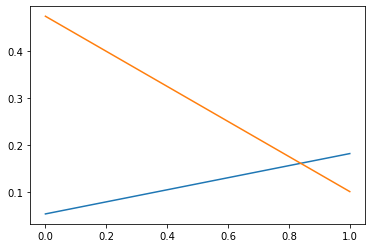

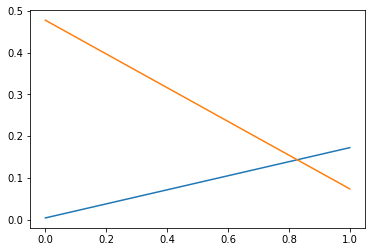

In [44]:
plt.figure()
plt.plot(test_losses)


plt.figure()
plt.plot(train_losses)